In [ ]:
######   preprocessing
import os
import pandas as pd

# ----------- PATHS -------------
input_folder = "../../data/raw/processed_data"
output_folder = "../../data/raw/lstm_data"

os.makedirs(output_folder, exist_ok=True)
# --------------------------------

for file in os.listdir(input_folder):
    if file.endswith(".csv"):
        input_path = os.path.join(input_folder, file)

        # Load csv
        df = pd.read_csv(input_path)

        # Fill only Unit1 & Unit2 with -1
        if "Unit1" in df.columns:
            df["Unit1"] = df["Unit1"].fillna(-1)

        if "Unit2" in df.columns:
            df["Unit2"] = df["Unit2"].fillna(-1)

        # Save cleaned version to output directory
        output_path = os.path.join(output_folder, file)
        df.to_csv(output_path, index=False)

        print(f"Cleaned and saved: {file}")

print("✅ ALL FILES PROCESSED & SAVED IN data/lstm/")


In [6]:
####### find max sequences length
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

data_dir = "../../data/raw/lstm_data/"

sequences = []
seq_lengths = []

for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_dir, file))

        # Convert to numpy array
        seq = df.values.astype(float)

        sequences.append(seq)
        seq_lengths.append(len(seq))

MAX_LEN = max(seq_lengths)
print("Max sequence length =", MAX_LEN)


Max sequence length = 336


In [7]:
######## padding
PAD_VALUE = -999

padded_sequences = []
for seq in sequences:
    pad_len = MAX_LEN - len(seq)
    if pad_len > 0:
        pad = np.full((pad_len, seq.shape[1]), PAD_VALUE)
        seq = np.vstack([seq, pad])
    padded_sequences.append(seq)

padded_sequences = np.array(padded_sequences)
print("Shape after padding:", padded_sequences.shape)


Shape after padding: (40336, 336, 13)


In [8]:
########## scaling
IGNORE_COLS = [0, 1]    # unit1, unit2
scaler = StandardScaler()

# 1. Reshape to 2D for scaling
N, T, F = padded_sequences.shape
flat = padded_sequences.reshape(-1, F)

# 2. Identify normal (non-pad) rows
valid_mask = (flat[:, 0] != PAD_VALUE)

# 3. Select only valid rows, and only non-ignore columns
cols_to_scale = [i for i in range(F) if i not in IGNORE_COLS]

valid_data = flat[valid_mask][:, cols_to_scale]

# 4. Fit scaler
scaler.fit(valid_data)

# 5. Transform ONLY valid rows, ONLY selected columns
flat_scaled = flat.copy()
flat_scaled[valid_mask][:, cols_to_scale] = scaler.transform(valid_data)

# 6. Restore padded rows unchanged
flat_scaled[~valid_mask] = PAD_VALUE

# 7. Reshape back to (patients, max_len, features)
scaled_sequences = flat_scaled.reshape(N, T, F)


In [2]:
import sys
print(sys.version)
!pip install tensorflow

3.12.0 | packaged by Anaconda, Inc. | (main, Oct  2 2023, 17:20:38) [MSC v.1916 64 bit (AMD64)]
  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.0.1-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached grpcio-1.76.0-cp312-cp312-win_amd64.whl.meta

In [3]:
import tensorflow
print(tensorflow.__version__)

2.20.0


In [10]:
labels = []

for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_dir, file))
        
        # Assuming the CSV has a column 'SepsisLabel' with 0/1 at each timestep
        # Take the max: 1 if patient ever got sepsis, else 0
        label = df['SepsisLabel'].max()
        labels.append(label)

labels = np.array(labels)
print("Labels shape:", labels.shape)


Labels shape: (40336,)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking

X = scaled_sequences
y = np.array(labels)   # you must supply patient-level labels

model = Sequential([
    Masking(mask_value=PAD_VALUE, input_shape=(MAX_LEN, F)),
    LSTM(64, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 336, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print("Sequences shape:", X.shape)   # (num_patients, MAX_LEN, F)
print("Labels shape:", y.shape)      # (num_patients,)


Sequences shape: (40336, 336, 13)
Labels shape: (40336,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [15]:
import numpy as np
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))


Train class distribution: [29922  2346]
Test class distribution: [7482  586]


In [16]:
import numpy as np

X_minority = X_train[y_train==1]
y_minority = y_train[y_train==1]

X_majority = X_train[y_train==0]
y_majority = y_train[y_train==0]

# Simple duplication
rep_factor = len(y_majority) // len(y_minority)
X_minority_dup = np.tile(X_minority, (rep_factor, 1, 1))
y_minority_dup = np.tile(y_minority, rep_factor)

# Combine
X_train_bal = np.vstack([X_majority, X_minority_dup])
y_train_bal = np.hstack([y_majority, y_minority_dup])

# Shuffle
idx = np.arange(len(y_train_bal))
np.random.shuffle(idx)
X_train_bal = X_train_bal[idx]
y_train_bal = y_train_bal[idx]


In [19]:
import numpy as np

print("Any NaNs in X_train_bal?", np.isnan(X_train_bal).any())
print("Max value:", np.max(X_train_bal))
print("Min value:", np.min(X_train_bal))


Any NaNs in X_train_bal? True
Max value: nan
Min value: nan


In [20]:
import numpy as np

# Check which sequences contain NaNs
nan_mask = np.isnan(X_train_bal).any(axis=(1,2))   # True for sequences with any NaN
print("Number of sequences with NaNs:", np.sum(nan_mask))

# Optionally, see indices
nan_indices = np.where(nan_mask)[0]
print("Indices of sequences with NaNs:", nan_indices)


Number of sequences with NaNs: 10669
Indices of sequences with NaNs: [   16    17    21 ... 58053 58060 58072]


In [21]:
X_train_bal = np.nan_to_num(X_train_bal, nan=PAD_VALUE)
X_test = np.nan_to_num(X_test, nan=PAD_VALUE)


In [22]:
print("Any NaNs in X_train_bal?", np.isnan(X_train_bal).any())
print("Any NaNs in X_test?", np.isnan(X_test).any())


Any NaNs in X_train_bal? False
Any NaNs in X_test? False


In [23]:
###### shuffling coz we padded
indices = np.arange(len(y_train_bal))
np.random.shuffle(indices)
X_train_bal = X_train_bal[indices]
y_train_bal = y_train_bal[indices]


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Masking(mask_value=PAD_VALUE, input_shape=(MAX_LEN, F)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),  # helps with stability and overfitting
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])


c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
history = model.fit(
    X_train_bal, y_train_bal,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)


Epoch 1/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 422s 286ms/step - accuracy: 0.7417 - loss: 0.5161 - val_accuracy: 0.8325 - val_loss: 0.3822
Epoch 2/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 386s 266ms/step - accuracy: 0.8969 - loss: 0.2325 - val_accuracy: 0.9431 - val_loss: 0.1278
Epoch 3/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 390s 268ms/step - accuracy: 0.9401 - loss: 0.1231 - val_accuracy: 0.9515 - val_loss: 0.1039
Epoch 4/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 353s 243ms/step - accuracy: 0.9528 - loss: 0.1049 - val_accuracy: 0.9580 - val_loss: 0.0972
Epoch 5/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 434s 299ms/step - accuracy: 0.9606 - loss: 0.0931 - val_accuracy: 0.9699 - val_loss: 0.0793
Epoch 6/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 390s 269ms/step - accuracy: 0.9708 - loss: 0.0790 - val_accuracy: 0.9821 - val_loss: 0.0635
Epoch 7/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 379s 261ms/step - accuracy: 0.9781 - loss: 0.0660 - val_accuracy: 0.9915 - val_loss: 0.0489
Epoch 8/20
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 397s 273ms/step - ac

In [30]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7482
           1       0.95      1.00      0.97       586

    accuracy                           1.00      8068
   macro avg       0.97      1.00      0.99      8068
weighted avg       1.00      1.00      1.00      8068

ROC-AUC: 0.9999990876853024
Accuracy: 0.9959097669806644


In [27]:
model.save("lstm_sepsis_model.h5")


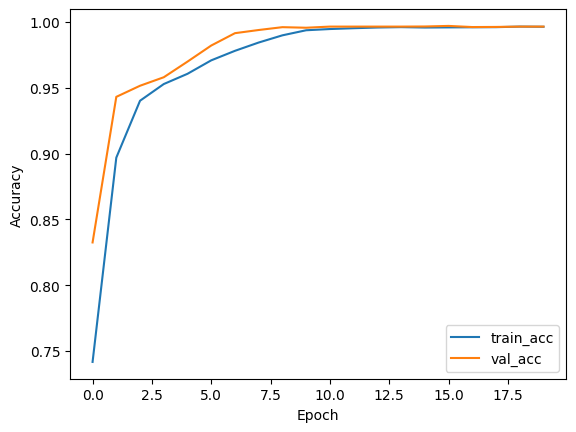

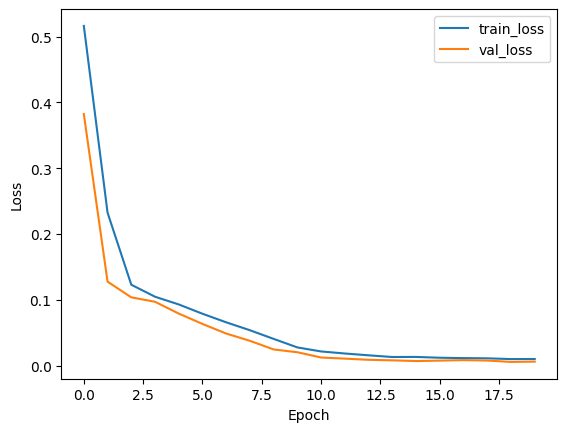

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
